# Análisis de Patrones - Riesgos Laborales Colombia

Este notebook implementa técnicas de análisis de patrones para identificar grupos de riesgo, tendencias temporales y anomalías en los datos de riesgos laborales.

## Objetivos:
1. Realizar análisis de clustering para identificar grupos de riesgo.
2. Implementar análisis de series temporales para detectar tendencias.
3. Detectar anomalías en los datos.
4. Generar insights accionables para la prevención de riesgos laborales.

## 1. Configuración Inicial

### 1.1 Importar Librerías

Importamos las librerías necesarias para el análisis de patrones.

In [1]:
# Instalar librerías necesarias
!pip install pandas numpy matplotlib seaborn scikit-learn plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 24.6 MB/s  0:00:00m0:00:0100:01


In [2]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
from pathlib import Path
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
import joblib

# Configuración de visualización
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Configuración de pandas para mostrar todas las columnas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


### 1.2 Montar Google Drive (para Colab)

Si estás ejecutando este notebook en Google Colab, es necesario montar Google Drive para acceder a los archivos del proyecto.

In [3]:
# Verificar si estamos en Google Colab
try:
    from google.colab import drive
    # Montar Google Drive
    drive.mount('/content/drive')
    # Definir ruta base del proyecto en Google Drive
    BASE_PATH = '/content/drive/MyDrive/DatosARLBog'
    print(f"✅ Google Drive montado correctamente")
    print(f"📁 Ruta base del proyecto: {BASE_PATH}")
except:
    # Si no estamos en Colab, usar la ruta local
    BASE_PATH = '/Users/jualgozo/Documents/datoscol/DatosArl_Mac'
    print(f"💻 Ejecutando en entorno local")
    print(f"📁 Ruta base del proyecto: {BASE_PATH}")

💻 Ejecutando en entorno local
📁 Ruta base del proyecto: /Users/jualgozo/Documents/datoscol/DatosArl_Mac


### 1.3 Definir Rutas de Archivos

Definimos las rutas de los archivos del proyecto.

In [4]:
# Definir rutas de archivos
DATA_PATH = Path(BASE_PATH)
PROCESSED_DATA_DIR = DATA_PATH / 'data' / 'processed'
MODELS_DIR = DATA_PATH / 'models'
REPORTS_DIR = DATA_PATH / 'reports'

# Crear directorios si no existen
MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"📂 Directorio de datos: {DATA_PATH}")
print(f"📁 Directorio de datos procesados: {PROCESSED_DATA_DIR}")
print(f"🤖 Directorio de modelos: {MODELS_DIR}")
print(f"📈 Directorio de reportes: {REPORTS_DIR}")

📂 Directorio de datos: /Users/jualgozo/Documents/datoscol/DatosArl_Mac
📁 Directorio de datos procesados: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/data/processed
🤖 Directorio de modelos: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/models
📈 Directorio de reportes: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/reports


## 2. Carga del Dataset Curado

### 2.1 Cargar el Dataset Procesado

Cargamos el dataset curado del notebook anterior.

In [5]:
# Cargar el dataset curado
try:
    # Intentar cargar desde el archivo CSV
    dataset_path = PROCESSED_DATA_DIR / 'dataset_curado.csv'
    df = pd.read_csv(dataset_path)
    print(f"✅ Dataset cargado correctamente desde: {dataset_path}")
except FileNotFoundError:
    # Si no existe, intentar cargar desde el archivo Parquet
    dataset_path = PROCESSED_DATA_DIR / 'dataset_curado.parquet'
    df = pd.read_parquet(dataset_path)
    print(f"✅ Dataset cargado correctamente desde: {dataset_path}")

print(f"\n📊 Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"\n📋 Columnas del dataset:")
print(df.columns.tolist())

✅ Dataset cargado correctamente desde: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/data/processed/dataset_curado.csv

📊 Dimensiones del dataset: 61368 filas x 26 columnas

📋 Columnas del dataset:
['DPTO', 'MPIO', 'CODIGO_DE_LA_ARL', 'AÑO_DE_INFORME', 'MES_DE_INFORME', 'ACTIVEC', 'RELA_DEP', 'RELA_INDEP', 'PRESUACCIDETRASUCE', 'MUERTES_REPOR_AT', 'NUEVAPENSIOINVA_R_AT', 'NUEVAPENSIOINVA_R_EL', 'INCAPERMAPARCIAR_AT', 'INCAPERMAPARCIAR_EL', 'DPTO_encoded', 'MPIO_encoded', 'RELA_DEP_encoded', 'RELA_INDEP_encoded', 'TASA_ACCIDENTES_DEP', 'TASA_MUERTES_DEP', 'TASA_PENSIONES_ACCIDENTE', 'TASA_PENSIONES_ENFERMEDAD', 'TOTAL_PENSIONES', 'TOTAL_INCAPACIDADES', 'RATIO_INDEP_DEP', 'TOTAL_TRABAJADORES']


In [6]:
# Mostrar las primeras filas del dataset
print("\n🔍 Primeras 5 filas del dataset:")
df.head()


🔍 Primeras 5 filas del dataset:


,DPTO,MPIO,CODIGO_DE_LA_ARL,AÑO_DE_INFORME,MES_DE_INFORME,ACTIVEC,RELA_DEP,RELA_INDEP,PRESUACCIDETRASUCE,MUERTES_REPOR_AT,NUEVAPENSIOINVA_R_AT,NUEVAPENSIOINVA_R_EL,INCAPERMAPARCIAR_AT,INCAPERMAPARCIAR_EL,DPTO_encoded,MPIO_encoded,RELA_DEP_encoded,RELA_INDEP_encoded,TASA_ACCIDENTES_DEP,TASA_MUERTES_DEP,TASA_PENSIONES_ACCIDENTE,TASA_PENSIONES_ENFERMEDAD,TOTAL_PENSIONES,TOTAL_INCAPACIDADES,RATIO_INDEP_DEP,TOTAL_TRABAJADORES
0,ANTIOQUIA,MEDELLIN,1423,2026,4,1131201,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,516,421,0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.00000,24.0
1,ANTIOQUIA,MEDELLIN,1423,2026,4,1131202,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,516,188,0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.00000,10.0
2,ANTIOQUIA,MEDELLIN,1423,2026,4,1139301,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,516,0,0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.00000,0.0
3,ANTIOQUIA,MEDELLIN,1423,2026,4,1141001,688.0,29.0,0.0,0.0,0.0,0.0,0.0,0.0,1,516,905,214,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.04209,717.0
4,ANTIOQUIA,MEDELLIN,1423,2026,4,1454101,323.0,0.0,2.0,2.0,2.0,0.0,0.0,0.0,1,516,551,0,0.006173,0.006173,0.666667,0.0,2.0,0.0,0.00000,323.0


### 2.2 Información del Dataset

Mostramos información general del dataset.

In [7]:
# Mostrar información del dataset
print("\n📋 Información del dataset:")
print(df.info())

print("\n📊 Estadísticas descriptivas:")
df.describe()


📋 Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 61368 entries, 0 to 61367
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   DPTO                       61368 non-null  str    
 1   MPIO                       61368 non-null  str    
 2   CODIGO_DE_LA_ARL           61368 non-null  int64  
 3   AÑO_DE_INFORME             61368 non-null  int64  
 4   MES_DE_INFORME             61368 non-null  int64  
 5   ACTIVEC                    61368 non-null  int64  
 6   RELA_DEP                   61368 non-null  float64
 7   RELA_INDEP                 61368 non-null  float64
 8   PRESUACCIDETRASUCE         61368 non-null  float64
 9   MUERTES_REPOR_AT           61368 non-null  float64
 10  NUEVAPENSIOINVA_R_AT       61368 non-null  float64
 11  NUEVAPENSIOINVA_R_EL       61368 non-null  float64
 12  INCAPERMAPARCIAR_AT        61368 non-null  float64
 13  INCAPERMAPARCIAR_EL        61

,CODIGO_DE_LA_ARL,AÑO_DE_INFORME,MES_DE_INFORME,ACTIVEC,RELA_DEP,RELA_INDEP,PRESUACCIDETRASUCE,MUERTES_REPOR_AT,NUEVAPENSIOINVA_R_AT,NUEVAPENSIOINVA_R_EL,INCAPERMAPARCIAR_AT,INCAPERMAPARCIAR_EL,DPTO_encoded,MPIO_encoded,RELA_DEP_encoded,RELA_INDEP_encoded,TASA_ACCIDENTES_DEP,TASA_MUERTES_DEP,TASA_PENSIONES_ACCIDENTE,TASA_PENSIONES_ENFERMEDAD,TOTAL_PENSIONES,TOTAL_INCAPACIDADES,RATIO_INDEP_DEP,TOTAL_TRABAJADORES
count,61368.0,61368.0,61368.0,6.136800e+04,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000
mean,1423.0,2026.0,4.0,2.905466e+06,44.391083,8.663098,0.135005,0.135005,0.135005,0.000244,0.000147,0.000033,14.763721,504.418687,299.722820,19.739376,0.002031,0.002031,0.029810,0.000007,0.135250,0.000179,0.422111,53.054181
std,0.0,0.0,0.0,1.294891e+06,614.021522,467.968900,1.894390,1.894390,1.894390,0.016642,0.012109,0.005709,9.540961,302.992084,331.924501,70.402446,0.025164,0.025164,0.133025,0.000844,1.899582,0.013387,7.399239,1010.197331
min,1423.0,2026.0,4.0,1.131201e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1423.0,2026.0,4.0,1.841201e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,240.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1423.0,2026.0,4.0,2.551101e+06,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,501.000000,229.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,1423.0,2026.0,4.0,3.711001e+06,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.000000,750.000000,536.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000
max,1423.0,2026.0,4.0,5.960901e+06,89723.000000,107082.000000,256.000000,256.000000,256.000000,2.000000,1.000000,1.000000,32.000000,1032.000000,1088.000000,417.000000,2.000000,2.000000,0.996109,0.142857,258.000000,1.000000,631.000000,196805.000000


## 3. Preparación de Datos para Análisis de Patrones

### 3.1 Seleccionar Variables para Clustering

Seleccionamos las variables numéricas relevantes para el análisis de clustering.

In [8]:
# Seleccionar variables numéricas para clustering
# Excluimos identificadores y variables objetivo
exclude_cols_clustering = ['CODIGO_DE_LA_ARL', 'AÑO_DE_INFORME', 'MES_DE_INFORME', 'ACTIVEC',
                          'DPTO', 'MPIO', 'DPTO_encoded', 'MPIO_encoded']

# Variables numéricas para clustering
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
clustering_cols = [col for col in numeric_cols if col not in exclude_cols_clustering]

print(f"📊 Variables seleccionadas para clustering ({len(clustering_cols)}):")
print(clustering_cols)

# Crear dataset para clustering
df_clustering = df[clustering_cols].copy()

# Manejar valores faltantes
print(f"\n📊 Valores faltantes por columna:")
print(df_clustering.isnull().sum())

# Rellenar valores faltantes con la mediana
for col in df_clustering.columns:
    df_clustering[col].fillna(df_clustering[col].median(), inplace=True)

print(f"\n✅ Valores faltantes después de imputación: {df_clustering.isnull().sum().sum()}")

📊 Variables seleccionadas para clustering (18):
['RELA_DEP', 'RELA_INDEP', 'PRESUACCIDETRASUCE', 'MUERTES_REPOR_AT', 'NUEVAPENSIOINVA_R_AT', 'NUEVAPENSIOINVA_R_EL', 'INCAPERMAPARCIAR_AT', 'INCAPERMAPARCIAR_EL', 'RELA_DEP_encoded', 'RELA_INDEP_encoded', 'TASA_ACCIDENTES_DEP', 'TASA_MUERTES_DEP', 'TASA_PENSIONES_ACCIDENTE', 'TASA_PENSIONES_ENFERMEDAD', 'TOTAL_PENSIONES', 'TOTAL_INCAPACIDADES', 'RATIO_INDEP_DEP', 'TOTAL_TRABAJADORES']

📊 Valores faltantes por columna:
RELA_DEP                     0
RELA_INDEP                   0
PRESUACCIDETRASUCE           0
MUERTES_REPOR_AT             0
NUEVAPENSIOINVA_R_AT         0
NUEVAPENSIOINVA_R_EL         0
INCAPERMAPARCIAR_AT          0
INCAPERMAPARCIAR_EL          0
RELA_DEP_encoded             0
RELA_INDEP_encoded           0
TASA_ACCIDENTES_DEP          0
TASA_MUERTES_DEP             0
TASA_PENSIONES_ACCIDENTE     0
TASA_PENSIONES_ENFERMEDAD    0
TOTAL_PENSIONES              0
TOTAL_INCAPACIDADES          0
RATIO_INDEP_DEP              0
TOT

### 3.2 Escalar Variables

Escalamos las variables para el análisis de clustering.

In [9]:
# Escalar variables para clustering
scaler_clustering = StandardScaler()
df_scaled = pd.DataFrame(
    scaler_clustering.fit_transform(df_clustering),
    columns=clustering_cols
)

print(f"✅ Variables escaladas correctamente")
print(f"📊 Dimensiones del dataset escalado: {df_scaled.shape}")
print(f"\n📊 Estadísticas del dataset escalado:")
print(df_scaled.describe())

✅ Variables escaladas correctamente
📊 Dimensiones del dataset escalado: (61368, 18)

📊 Estadísticas del dataset escalado:
           RELA_DEP    RELA_INDEP  PRESUACCIDETRASUCE  MUERTES_REPOR_AT  \
count  6.136800e+04  6.136800e+04        6.136800e+04      6.136800e+04   
mean   3.705085e-18 -2.778814e-18       -1.018898e-17     -1.018898e-17   
std    1.000008e+00  1.000008e+00        1.000008e+00      1.000008e+00   
min   -7.229624e-02 -1.851227e-02       -7.126639e-02     -7.126639e-02   
25%   -7.229624e-02 -1.851227e-02       -7.126639e-02     -7.126639e-02   
50%   -6.903899e-02 -1.851227e-02       -7.126639e-02     -7.126639e-02   
75%   -5.438141e-02 -1.851227e-02       -7.126639e-02     -7.126639e-02   
max    1.460524e+02  2.288063e+02        1.350657e+02      1.350657e+02   

       NUEVAPENSIOINVA_R_AT  NUEVAPENSIOINVA_R_EL  INCAPERMAPARCIAR_AT  \
count          6.136800e+04          6.136800e+04         6.136800e+04   
mean          -1.018898e-17          1.852543e-18     

## 4. Análisis de Clustering

### 4.1 K-Means Clustering

Implementamos K-Means para identificar grupos de riesgo.

#### 4.1.1 Método del Codo para Determinar K Óptimo

📊 Calculando inercia para diferentes valores de K...
   K=2: Inercia=869088.23, Silhouette=0.9956
   K=3: Inercia=741114.60, Silhouette=0.9802
   K=4: Inercia=642403.92, Silhouette=0.9783
   K=5: Inercia=546549.02, Silhouette=0.7760
   K=6: Inercia=467774.41, Silhouette=0.7698
   K=7: Inercia=398985.42, Silhouette=0.7680
   K=8: Inercia=352570.84, Silhouette=0.5764
   K=9: Inercia=311720.42, Silhouette=0.6391
   K=10: Inercia=274870.73, Silhouette=0.6397


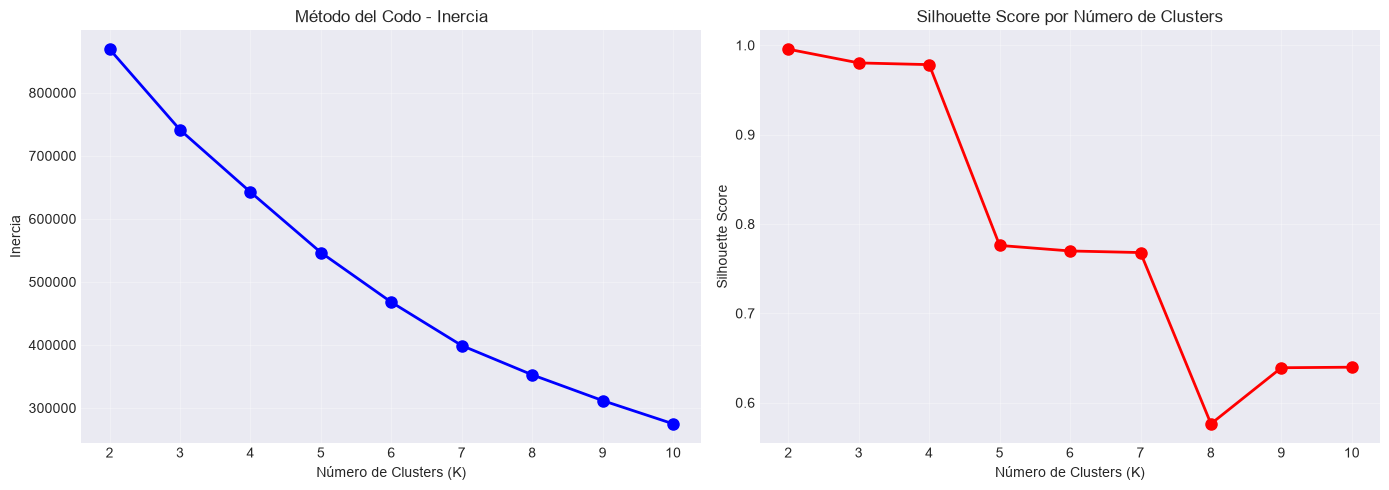


✅ Gráfico guardado en: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/reports/elbow_method.png


In [10]:
# Método del codo para determinar el número óptimo de clusters
print("📊 Calculando inercia para diferentes valores de K...")

inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertias.append(kmeans.inertia_)
    
    # Calcular silhouette score
    labels = kmeans.labels_
    silhouette_avg = silhouette_score(df_scaled, labels)
    silhouette_scores.append(silhouette_avg)
    
    print(f"   K={k}: Inercia={kmeans.inertia_:.2f}, Silhouette={silhouette_avg:.4f}")

# Visualizar método del codo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de inercia
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del Codo - Inercia')
axes[0].grid(True, alpha=0.3)

# Gráfico de silhouette score
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score por Número de Clusters')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'elbow_method.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✅ Gráfico guardado en: {REPORTS_DIR / 'elbow_method.png'}")

#### 4.1.2 Entrenar K-Means con K Óptimo

In [11]:
# Seleccionar K óptimo basado en el análisis anterior
# Usaremos K=4 como ejemplo (ajustar según los resultados del método del codo)
optimal_k = 4

print(f"🎯 Entrenando K-Means con K={optimal_k}...")
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(df_scaled)

# Agregar etiquetas de cluster al dataset original
df['CLUSTER_KMEANS'] = kmeans_labels

# Calcular métricas de evaluación
silhouette_avg = silhouette_score(df_scaled, kmeans_labels)
calinski_harabasz = calinski_harabasz_score(df_scaled, kmeans_labels)
davies_bouldin = davies_bouldin_score(df_scaled, kmeans_labels)

print(f"\n📊 Métricas de evaluación - K-Means (K={optimal_k}):")
print(f"   Silhouette Score: {silhouette_avg:.4f}")
print(f"   Calinski-Harabasz Index: {calinski_harabasz:.4f}")
print(f"   Davies-Bouldin Index: {davies_bouldin:.4f}")

# Distribución de clusters
print(f"\n📊 Distribución de clusters:")
print(df['CLUSTER_KMEANS'].value_counts().sort_index())

🎯 Entrenando K-Means con K=4...

📊 Métricas de evaluación - K-Means (K=4):
   Silhouette Score: 0.9783
   Calinski-Harabasz Index: 14717.4655
   Davies-Bouldin Index: 0.4437

📊 Distribución de clusters:
CLUSTER_KMEANS
0    61343
1        1
2       15
3        9
Name: count, dtype: int64


#### 4.1.3 Visualizar Clusters con PCA

📊 Aplicando PCA para visualización...


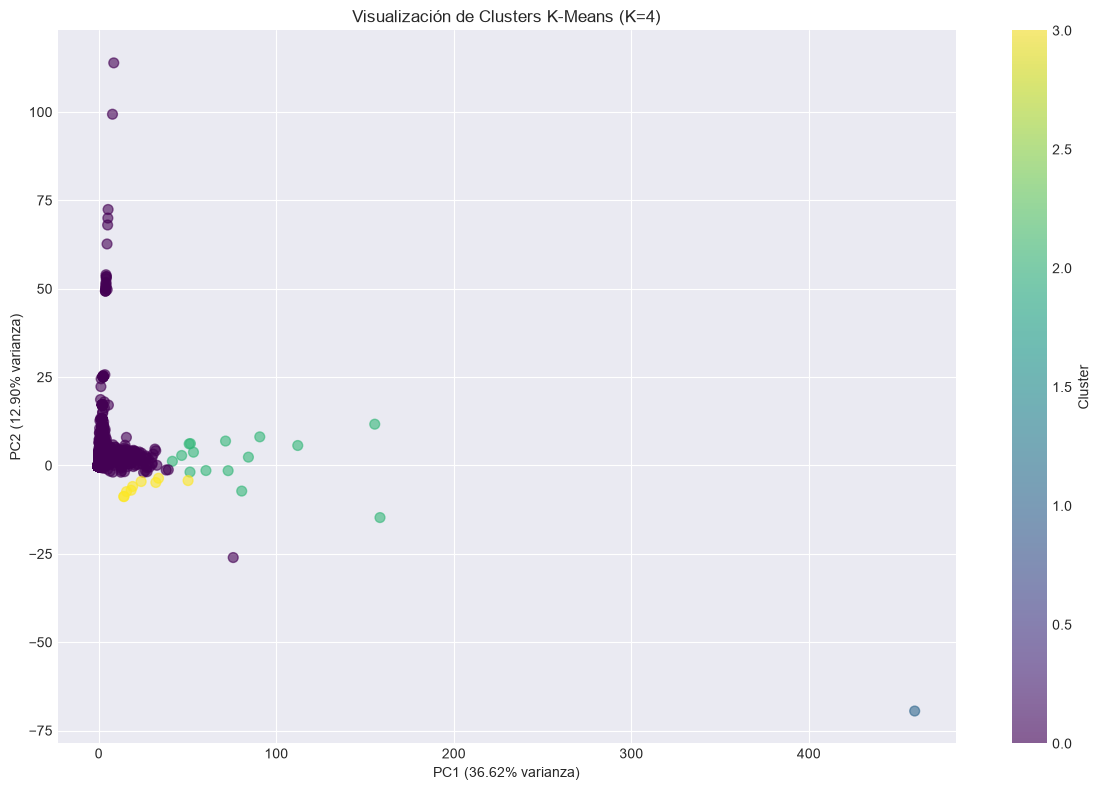


✅ Gráfico guardado en: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/reports/kmeans_clusters_pca.png

📊 Varianza explicada por componentes principales:
   PC1: 36.62%
   PC2: 12.90%
   Total: 49.52%


In [12]:
# Reducir dimensionalidad con PCA para visualización
print("📊 Aplicando PCA para visualización...")
pca = PCA(n_components=2)
df_pca = pd.DataFrame(
    pca.fit_transform(df_scaled),
    columns=['PC1', 'PC2']
)
df_pca['CLUSTER'] = kmeans_labels

# Visualizar clusters
plt.figure(figsize=(12, 8))
scatter = plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['CLUSTER'], 
                      cmap='viridis', alpha=0.6, s=50)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% varianza)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% varianza)')
plt.title(f'Visualización de Clusters K-Means (K={optimal_k})')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'kmeans_clusters_pca.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✅ Gráfico guardado en: {REPORTS_DIR / 'kmeans_clusters_pca.png'}")

print(f"\n📊 Varianza explicada por componentes principales:")
print(f"   PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"   PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"   Total: {sum(pca.explained_variance_ratio_)*100:.2f}%")

#### 4.1.4 Análisis de Características por Cluster

📊 Análisis de características por cluster:

📊 Promedio de variables por cluster:
                    RELA_DEP     RELA_INDEP  PRESUACCIDETRASUCE  \
CLUSTER_KMEANS                                                    
0                  38.330991       5.995990            0.111113   
1               89723.000000  107082.000000          256.000000   
2               18127.600000    3777.066667           74.133333   
3                1246.333333       9.666667           11.222222   

                MUERTES_REPOR_AT  NUEVAPENSIOINVA_R_AT  NUEVAPENSIOINVA_R_EL  \
CLUSTER_KMEANS                                                                 
0                       0.111113              0.111113              0.000196   
1                     256.000000            256.000000              2.000000   
2                      74.133333             74.133333              0.066667   
3                      11.222222             11.222222              0.000000   

                INCAPERMAPARCIAR_AT

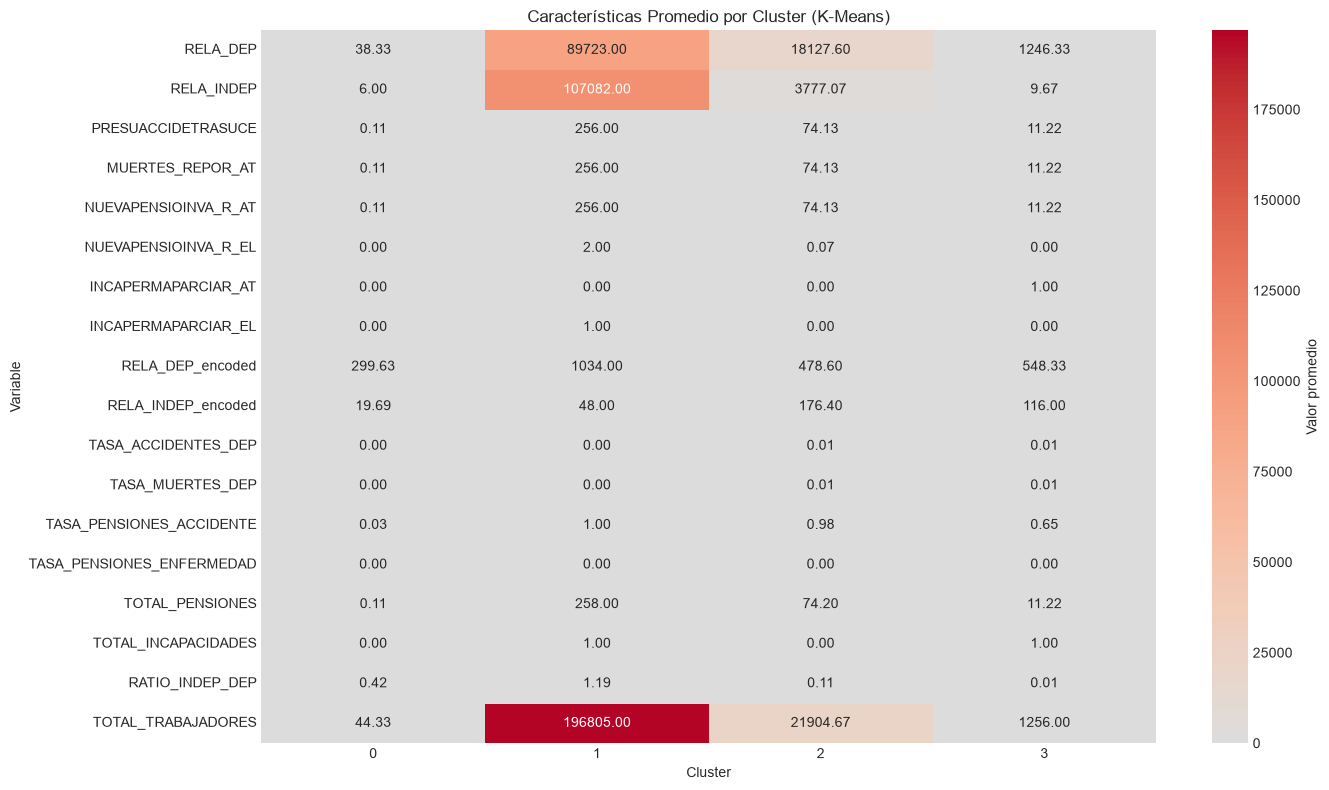


✅ Gráfico guardado en: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/reports/cluster_characteristics_heatmap.png


In [13]:
# Analizar características por cluster
print("📊 Análisis de características por cluster:")

# Calcular estadísticas por cluster
cluster_stats = df.groupby('CLUSTER_KMEANS')[clustering_cols].mean()
print("\n📊 Promedio de variables por cluster:")
print(cluster_stats)

# Visualizar heatmap de características por cluster
plt.figure(figsize=(14, 8))
sns.heatmap(cluster_stats.T, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, cbar_kws={'label': 'Valor promedio'})
plt.title('Características Promedio por Cluster (K-Means)')
plt.xlabel('Cluster')
plt.ylabel('Variable')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'cluster_characteristics_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✅ Gráfico guardado en: {REPORTS_DIR / 'cluster_characteristics_heatmap.png'}")

### 4.2 DBSCAN Clustering

Implementamos DBSCAN para identificar clusters de densidad variable.

#### 4.2.1 Determinar Epsilon Óptimo

📊 Calculando k-distance graph para determinar epsilon...


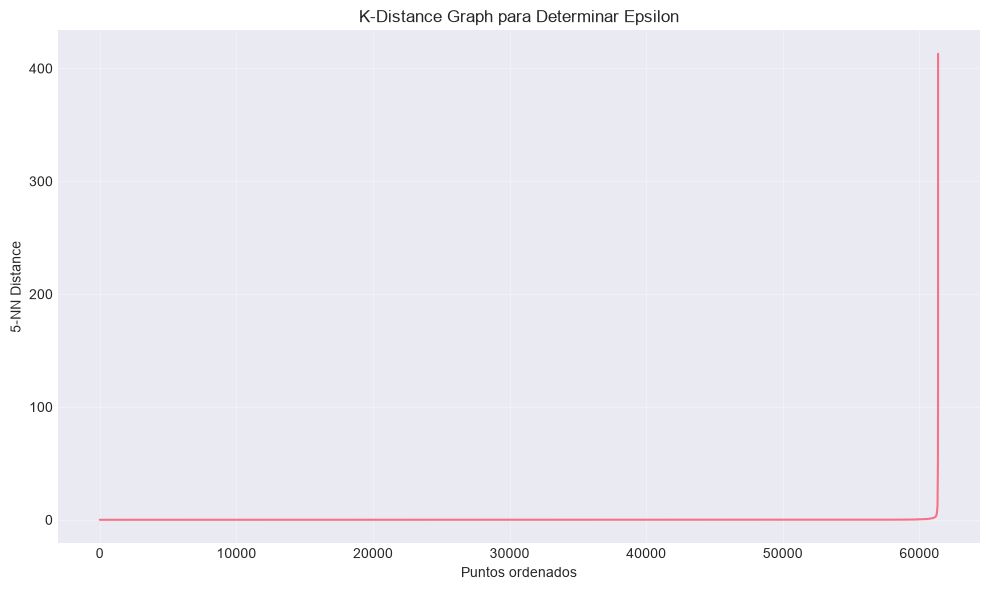


✅ Gráfico guardado en: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/reports/k_distance_graph.png

📊 ANÁLISIS AUTOMÁTICO DE EPSILON

📊 Candidatos de epsilon (ordenados):
   0.114889
   0.302575
   18.543962

📊 Probando DBSCAN para cada candidato:
------------------------------------------------------------

📌 min_samples = 5
------------------------------------------------------------
   eps=0.114889 -> clusters=219, ruido=  2775 ( 4.52%), silhouette=0.6275
   eps=0.302575 -> clusters= 88, ruido=  1342 ( 2.19%), silhouette=0.5021
   eps=18.543962 -> clusters=  4, ruido=    27 ( 0.04%), silhouette=0.9644

📌 min_samples = 19
------------------------------------------------------------
   eps=0.114889 -> clusters= 52, ruido=  4824 ( 7.86%), silhouette=0.5932
   eps=0.302575 -> clusters= 31, ruido=  2390 ( 3.89%), silhouette=0.4264
   eps=18.543962 -> clusters=  1, ruido=    59 ( 0.10%), silhouette=N/A

💡 Recomendación:
   - Buscar configuración con número de clusters razonable (>1)
   

In [14]:
# Determinar epsilon óptimo usando k-distance graph y análisis automático
print("📊 Calculando k-distance graph para determinar epsilon...")

# Calcular k-distance
k = 5  # Número de vecinos
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(df_scaled)
distances, indices = neighbors_fit.kneighbors(df_scaled)

# Ordenar distancias
distances = np.sort(distances[:, k-1], axis=0)

# Visualizar k-distance graph
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.xlabel('Puntos ordenados')
plt.ylabel(f'{k}-NN Distance')
plt.title('K-Distance Graph para Determinar Epsilon')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'k_distance_graph.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✅ Gráfico guardado en: {REPORTS_DIR / 'k_distance_graph.png'}")

# Calcular candidatos de epsilon automáticamente
print("\n" + "="*60)
print("📊 ANÁLISIS AUTOMÁTICO DE EPSILON")
print("="*60)

# Suavizar la curva y detectar la 'rodilla' por segunda derivada
window = max(3, int(len(distances)*0.001))  # pequeño suavizado
dist_smooth = np.convolve(distances, np.ones(window)/window, mode='same')
first = np.gradient(dist_smooth)
second = np.gradient(first)
idx_knee = np.argmax(second)
eps_knee = distances[idx_knee]

# Candidatos basados en percentiles y la rodilla detectada
eps_p90 = np.percentile(distances, 90)
eps_p95 = np.percentile(distances, 95)
eps_p97_5 = np.percentile(distances, 97.5)

# Filtrar candidatos: epsilon debe ser > 0 y razonable
all_candidates = [eps_knee, eps_p90, eps_p95, eps_p97_5]
candidates = sorted(set([e for e in all_candidates if e > 0.01]))  # mínimo 0.01

# Si no hay suficientes candidatos, agregar valores por defecto
if len(candidates) < 3:
    candidates = [0.5, 1.0, 2.0, 3.0, 5.0]

print(f"\n📊 Candidatos de epsilon (ordenados):")
for e in candidates:
    print(f"   {e:.6f}")

# Probar DBSCAN con cada candidato y reportar resultados
print("\n📊 Probando DBSCAN para cada candidato:")
print("-" * 60)

# Usar min_samples = número de dimensiones + 1 (regla común para datos de alta dimensión)
min_samples_default = df_scaled.shape[1] + 1
min_samples_options = [5, min_samples_default]

for min_samples in min_samples_options:
    print(f"\n📌 min_samples = {min_samples}")
    print("-" * 60)
    for e in candidates:
        try:
            db = DBSCAN(eps=e, min_samples=min_samples)
            labels = db.fit_predict(df_scaled)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = int((labels == -1).sum())
            noise_pct = n_noise/len(labels)*100
            
            # Calcular silhouette solo si hay más de 1 cluster
            if n_clusters > 1:
                sil = silhouette_score(df_scaled, labels)
                print(f"   eps={e:.6f} -> clusters={n_clusters:3d}, ruido={n_noise:6d} ({noise_pct:5.2f}%), silhouette={sil:.4f}")
            else:
                print(f"   eps={e:.6f} -> clusters={n_clusters:3d}, ruido={n_noise:6d} ({noise_pct:5.2f}%), silhouette=N/A")
        except Exception as ex:
            print(f"   eps={e:.6f} -> ERROR: {str(ex)[:50]}")

print("\n" + "="*60)
print("💡 Recomendación:")
print("   - Buscar configuración con número de clusters razonable (>1)")
print("   - Porcentaje de ruido moderado (0.5% - 5%)")
print("   - Silhouette score más alto posible")
print("="*60)

#### 4.2.2 Entrenar DBSCAN

In [24]:
# Entrenar DBSCAN con parámetros ajustados
# Epsilon y min_samples deben ajustarse según el k-distance graph
epsilon = 18.543962  # Ajustar según el k-distance graph
min_samples = 5

print(f"🎯 Entrenando DBSCAN con epsilon={epsilon} y min_samples={min_samples}...")
dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
dbscan_labels = dbscan.fit_predict(df_scaled)

# Agregar etiquetas de cluster al dataset
df['CLUSTER_DBSCAN'] = dbscan_labels

# Número de clusters (excluyendo ruido)
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"\n📊 Resultados DBSCAN:")
print(f"   Número de clusters: {n_clusters}")
print(f"   Puntos de ruido: {n_noise} ({n_noise/len(dbscan_labels)*100:.2f}%)")

# Distribución de clusters
print(f"\n📊 Distribución de clusters:")
print(df['CLUSTER_DBSCAN'].value_counts().sort_index())

🎯 Entrenando DBSCAN con epsilon=18.543962 y min_samples=5...

📊 Resultados DBSCAN:
   Número de clusters: 4
   Puntos de ruido: 28 (0.05%)

📊 Distribución de clusters:
CLUSTER_DBSCAN
-1       28
 0    61310
 1        8
 2        8
 3       14
Name: count, dtype: int64


#### 4.2.3 Visualizar DBSCAN Clusters

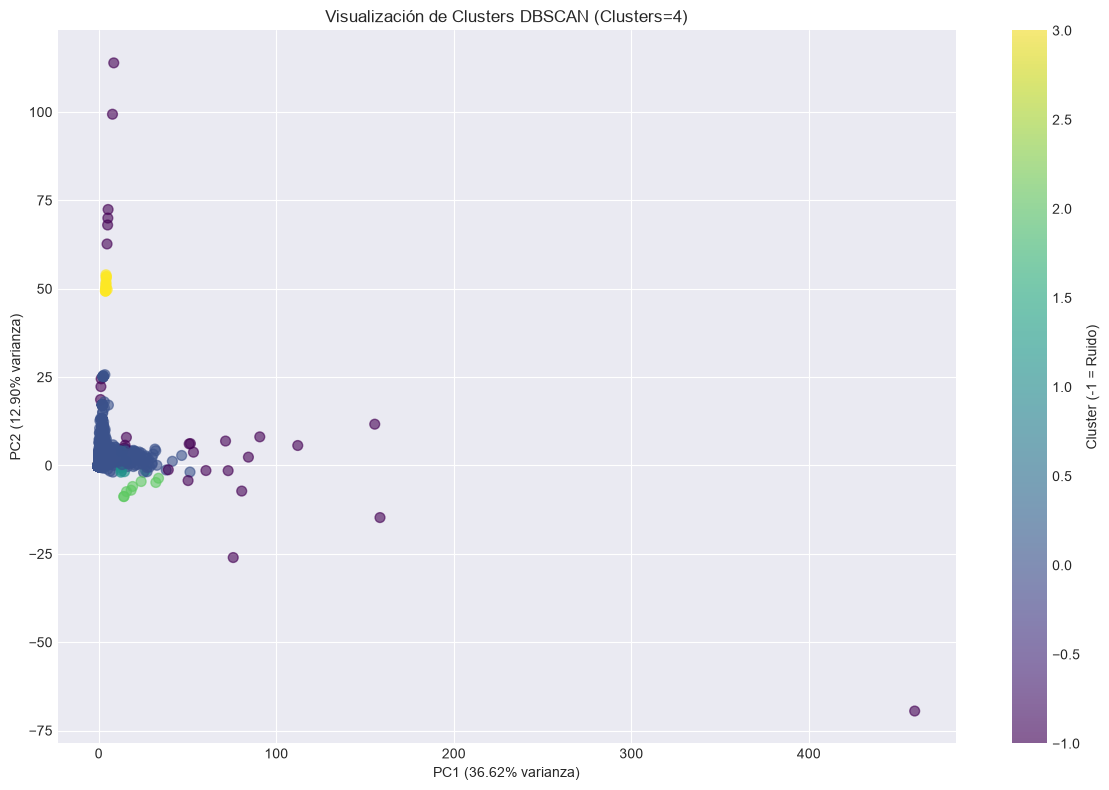


✅ Gráfico guardado en: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/reports/dbscan_clusters_pca.png


In [25]:
# Visualizar DBSCAN clusters con PCA
df_pca['CLUSTER_DBSCAN'] = dbscan_labels

plt.figure(figsize=(12, 8))
scatter = plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['CLUSTER_DBSCAN'], 
                      cmap='viridis', alpha=0.6, s=50)
plt.colorbar(scatter, label='Cluster (-1 = Ruido)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% varianza)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% varianza)')
plt.title(f'Visualización de Clusters DBSCAN (Clusters={n_clusters})')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'dbscan_clusters_pca.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✅ Gráfico guardado en: {REPORTS_DIR / 'dbscan_clusters_pca.png'}")

## 5. Detección de Anomalías

### 5.1 Isolation Forest

Implementamos Isolation Forest para detectar anomalías en los datos.

In [26]:
# Entrenar Isolation Forest para detección de anomalías
print("🔍 Entrenando Isolation Forest para detección de anomalías...")

contamination = 0.05  # Proporción esperada de anomalías
iso_forest = IsolationForest(
    contamination=contamination,
    random_state=42,
    n_jobs=-1
)

anomaly_labels = iso_forest.fit_predict(df_scaled)
anomaly_scores = iso_forest.score_samples(df_scaled)

# Agregar resultados al dataset
df['ANOMALY'] = anomaly_labels
df['ANOMALY_SCORE'] = anomaly_scores

# Convertir etiquetas: 1 = normal, -1 = anomalía
df['ANOMALY'] = df['ANOMALY'].map({1: 0, -1: 1})  # 0 = normal, 1 = anomalía

# Contar anomalías
n_anomalies = df['ANOMALY'].sum()
n_normal = len(df) - n_anomalies

print(f"\n📊 Resultados de detección de anomalías:")
print(f"   Registros normales: {n_normal} ({n_normal/len(df)*100:.2f}%)")
print(f"   Anomalías detectadas: {n_anomalies} ({n_anomalies/len(df)*100:.2f}%)")

🔍 Entrenando Isolation Forest para detección de anomalías...

📊 Resultados de detección de anomalías:
   Registros normales: 58306 (95.01%)
   Anomalías detectadas: 3062 (4.99%)


### 5.2 Visualizar Anomalías

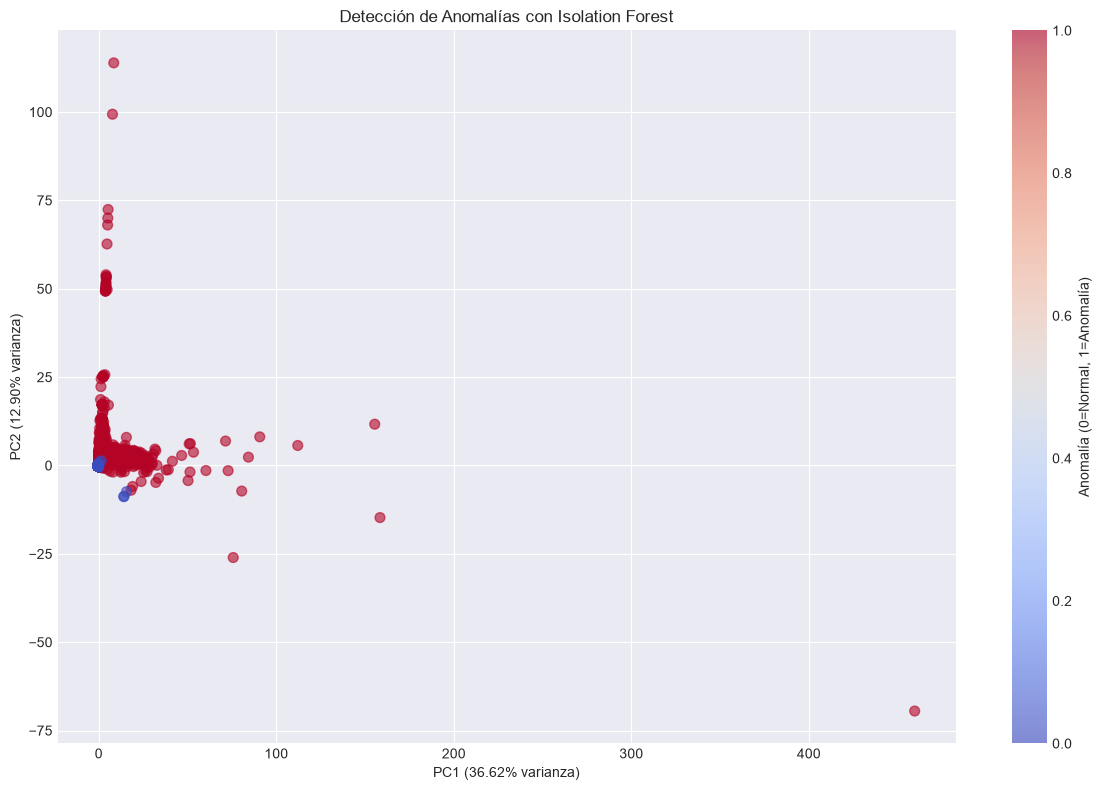


✅ Gráfico guardado en: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/reports/anomaly_detection_pca.png


In [27]:
# Visualizar anomalías con PCA
df_pca['ANOMALY'] = df['ANOMALY']

plt.figure(figsize=(12, 8))
scatter = plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['ANOMALY'], 
                      cmap='coolwarm', alpha=0.6, s=50)
plt.colorbar(scatter, label='Anomalía (0=Normal, 1=Anomalía)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% varianza)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% varianza)')
plt.title('Detección de Anomalías con Isolation Forest')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'anomaly_detection_pca.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✅ Gráfico guardado en: {REPORTS_DIR / 'anomaly_detection_pca.png'}")

### 5.3 Análisis de Anomalías

📊 Análisis de anomalías:

📊 Estadísticas de registros normales:
                                 mean         std
RELA_DEP                    14.124275   44.473110
RELA_INDEP                   1.001767    6.936755
PRESUACCIDETRASUCE           0.013275    0.114450
MUERTES_REPOR_AT             0.013275    0.114450
NUEVAPENSIOINVA_R_AT         0.013275    0.114450
NUEVAPENSIOINVA_R_EL         0.000000    0.000000
INCAPERMAPARCIAR_AT          0.000051    0.007173
INCAPERMAPARCIAR_EL          0.000000    0.000000
RELA_DEP_encoded           289.195983  329.291330
RELA_INDEP_encoded          12.932854   56.454562
TASA_ACCIDENTES_DEP          0.000190    0.001916
TASA_MUERTES_DEP             0.000190    0.001916
TASA_PENSIONES_ACCIDENTE     0.006637    0.057225
TASA_PENSIONES_ENFERMEDAD    0.000000    0.000000
TOTAL_PENSIONES              0.013275    0.114450
TOTAL_INCAPACIDADES          0.000051    0.007173
RATIO_INDEP_DEP              0.127152    0.802070
TOTAL_TRABAJADORES          15.12604

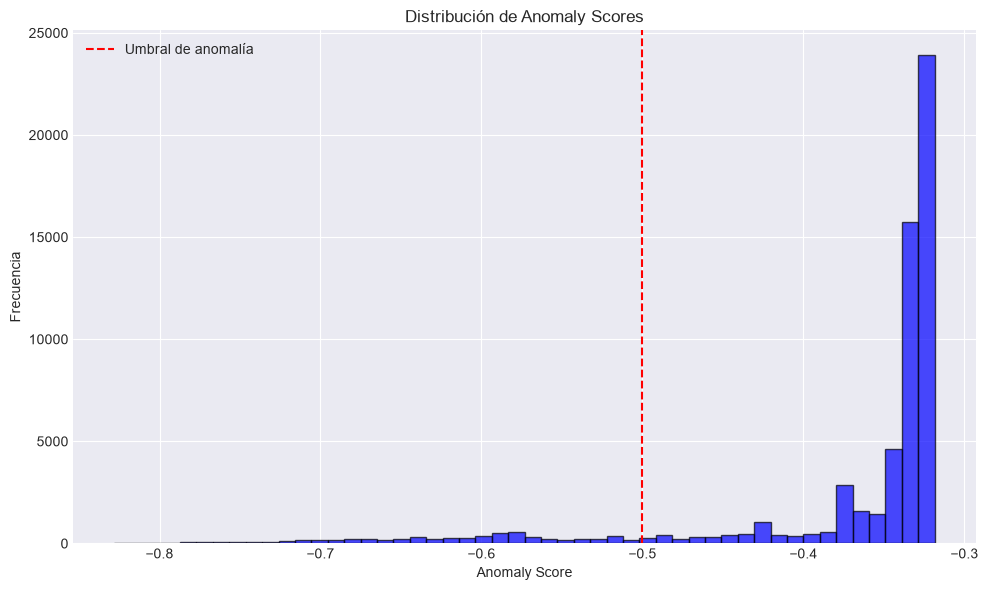


✅ Gráfico guardado en: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/reports/anomaly_score_distribution.png


In [28]:
# Analizar características de anomalías
print("📊 Análisis de anomalías:")

# Comparar estadísticas de registros normales vs anomalías
normal_stats = df[df['ANOMALY'] == 0][clustering_cols].describe()
anomaly_stats = df[df['ANOMALY'] == 1][clustering_cols].describe()

print("\n📊 Estadísticas de registros normales:")
print(normal_stats.loc[['mean', 'std']].T)

print("\n📊 Estadísticas de anomalías:")
print(anomaly_stats.loc[['mean', 'std']].T)

# Visualizar distribución de scores de anomalía
plt.figure(figsize=(10, 6))
plt.hist(df['ANOMALY_SCORE'], bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(x=-0.5, color='red', linestyle='--', label='Umbral de anomalía')
plt.xlabel('Anomaly Score')
plt.ylabel('Frecuencia')
plt.title('Distribución de Anomaly Scores')
plt.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'anomaly_score_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✅ Gráfico guardado en: {REPORTS_DIR / 'anomaly_score_distribution.png'}")

## 6. Análisis Temporal

### 6.1 Preparar Datos para Análisis Temporal

In [29]:
# Preparar datos para análisis temporal
print("📊 Preparando datos para análisis temporal...")

# Crear columna de fecha
df['FECHA'] = pd.to_datetime(df['AÑO_DE_INFORME'].astype(str) + '-' + 
                             df['MES_DE_INFORME'].astype(str).str.zfill(2) + '-01')

# Agrupar por fecha
df_temporal = df.groupby('FECHA').agg({
    'PRESUACCIDETRASUCE': 'sum',
    'MUERTES_REPOR_AT': 'sum',
    'NUEVAPENSIOINVA_R_AT': 'sum',
    'INCAPERMAPARCIAR_AT': 'sum',
    'RELA_DEP': 'sum',
    'RELA_INDEP': 'sum'
}).reset_index()

print(f"\n📊 Datos temporales preparados:")
print(f"   Período: {df_temporal['FECHA'].min()} a {df_temporal['FECHA'].max()}")
print(f"   Número de períodos: {len(df_temporal)}")
print(f"\n📊 Primeras filas:")
print(df_temporal.head())

📊 Preparando datos para análisis temporal...

📊 Datos temporales preparados:
   Período: 2026-04-01 00:00:00 a 2026-04-01 00:00:00
   Número de períodos: 1

📊 Primeras filas:
       FECHA  PRESUACCIDETRASUCE  MUERTES_REPOR_AT  NUEVAPENSIOINVA_R_AT  \
0 2026-04-01              8285.0            8285.0                8285.0   

   INCAPERMAPARCIAR_AT   RELA_DEP  RELA_INDEP  
0                  9.0  2724192.0    531637.0  


In [33]:
# DEBUG: Verificar preparación de datos temporales
print("🔍 DEBUG: Verificando datos temporales...")
print(f"📋 Columnas en df: {df.columns.tolist()}")
print()

# Verificar columnas requeridas
required_cols = ['AÑO_DE_INFORME', 'MES_DE_INFORME', 'PRESUACCIDETRASUCE', 'MUERTES_REPOR_AT', 
                 'NUEVAPENSIOINVA_R_AT', 'INCAPERMAPARCIAR_AT', 'RELA_DEP', 'RELA_INDEP']
for col in required_cols:
    if col in df.columns:
        print(f"✅ {col}: min={df[col].min()}, max={df[col].max()}, nulls={df[col].isnull().sum()}, dtype={df[col].dtype}")
    else:
        print(f"❌ {col}: NO ENCONTRADA")

# Verificar FECHA
if 'FECHA' in df.columns:
    print(f"\n📅 FECHA: min={df['FECHA'].min()}, max={df['FECHA'].max()}, nulls={df['FECHA'].isnull().sum()}")
else:
    print("\n❌ FECHA no existe - creándola...")
    df['FECHA'] = pd.to_datetime(df['AÑO_DE_INFORME'].astype(str) + '-' + 
                                 df['MES_DE_INFORME'].astype(str).str.zfill(2) + '-01')
    print(f"   FECHA creada: min={df['FECHA'].min()}, max={df['FECHA'].max()}")

# Verificar df_temporal
if 'df_temporal' in locals():
    print(f"\n📊 df_temporal shape: {df_temporal.shape}")
    print(f"   Período: {df_temporal['FECHA'].min()} a {df_temporal['FECHA'].max()}")
    print(f"   Columnas: {df_temporal.columns.tolist()}")
    print(f"\n📊 Primeras 5 filas:")
    print(df_temporal.head())
    print(f"\n📊 Valores nulos:")
    print(df_temporal.isnull().sum())
else:
    print("\n❌ df_temporal no existe - creándola...")
    df_temporal = df.groupby('FECHA').agg({
        'PRESUACCIDETRASUCE': 'sum',
        'MUERTES_REPOR_AT': 'sum',
        'NUEVAPENSIOINVA_R_AT': 'sum',
        'INCAPERMAPARCIAR_AT': 'sum',
        'RELA_DEP': 'sum',
        'RELA_INDEP': 'sum'
    }).reset_index()
    print(f"   df_temporal creada: shape={df_temporal.shape}")
    print(df_temporal.head())

🔍 DEBUG: Verificando datos temporales...
📋 Columnas en df: ['DPTO', 'MPIO', 'CODIGO_DE_LA_ARL', 'AÑO_DE_INFORME', 'MES_DE_INFORME', 'ACTIVEC', 'RELA_DEP', 'RELA_INDEP', 'PRESUACCIDETRASUCE', 'MUERTES_REPOR_AT', 'NUEVAPENSIOINVA_R_AT', 'NUEVAPENSIOINVA_R_EL', 'INCAPERMAPARCIAR_AT', 'INCAPERMAPARCIAR_EL', 'DPTO_encoded', 'MPIO_encoded', 'RELA_DEP_encoded', 'RELA_INDEP_encoded', 'TASA_ACCIDENTES_DEP', 'TASA_MUERTES_DEP', 'TASA_PENSIONES_ACCIDENTE', 'TASA_PENSIONES_ENFERMEDAD', 'TOTAL_PENSIONES', 'TOTAL_INCAPACIDADES', 'RATIO_INDEP_DEP', 'TOTAL_TRABAJADORES', 'CLUSTER_KMEANS', 'CLUSTER_DBSCAN', 'ANOMALY', 'ANOMALY_SCORE', 'FECHA']

✅ AÑO_DE_INFORME: min=2026, max=2026, nulls=0, dtype=int64
✅ MES_DE_INFORME: min=4, max=4, nulls=0, dtype=int64
✅ PRESUACCIDETRASUCE: min=0.0, max=256.0, nulls=0, dtype=float64
✅ MUERTES_REPOR_AT: min=0.0, max=256.0, nulls=0, dtype=float64
✅ NUEVAPENSIOINVA_R_AT: min=0.0, max=256.0, nulls=0, dtype=float64
✅ INCAPERMAPARCIAR_AT: min=0.0, max=1.0, nulls=0, dtype=f

### 6.2 Visualizar Tendencias Temporales

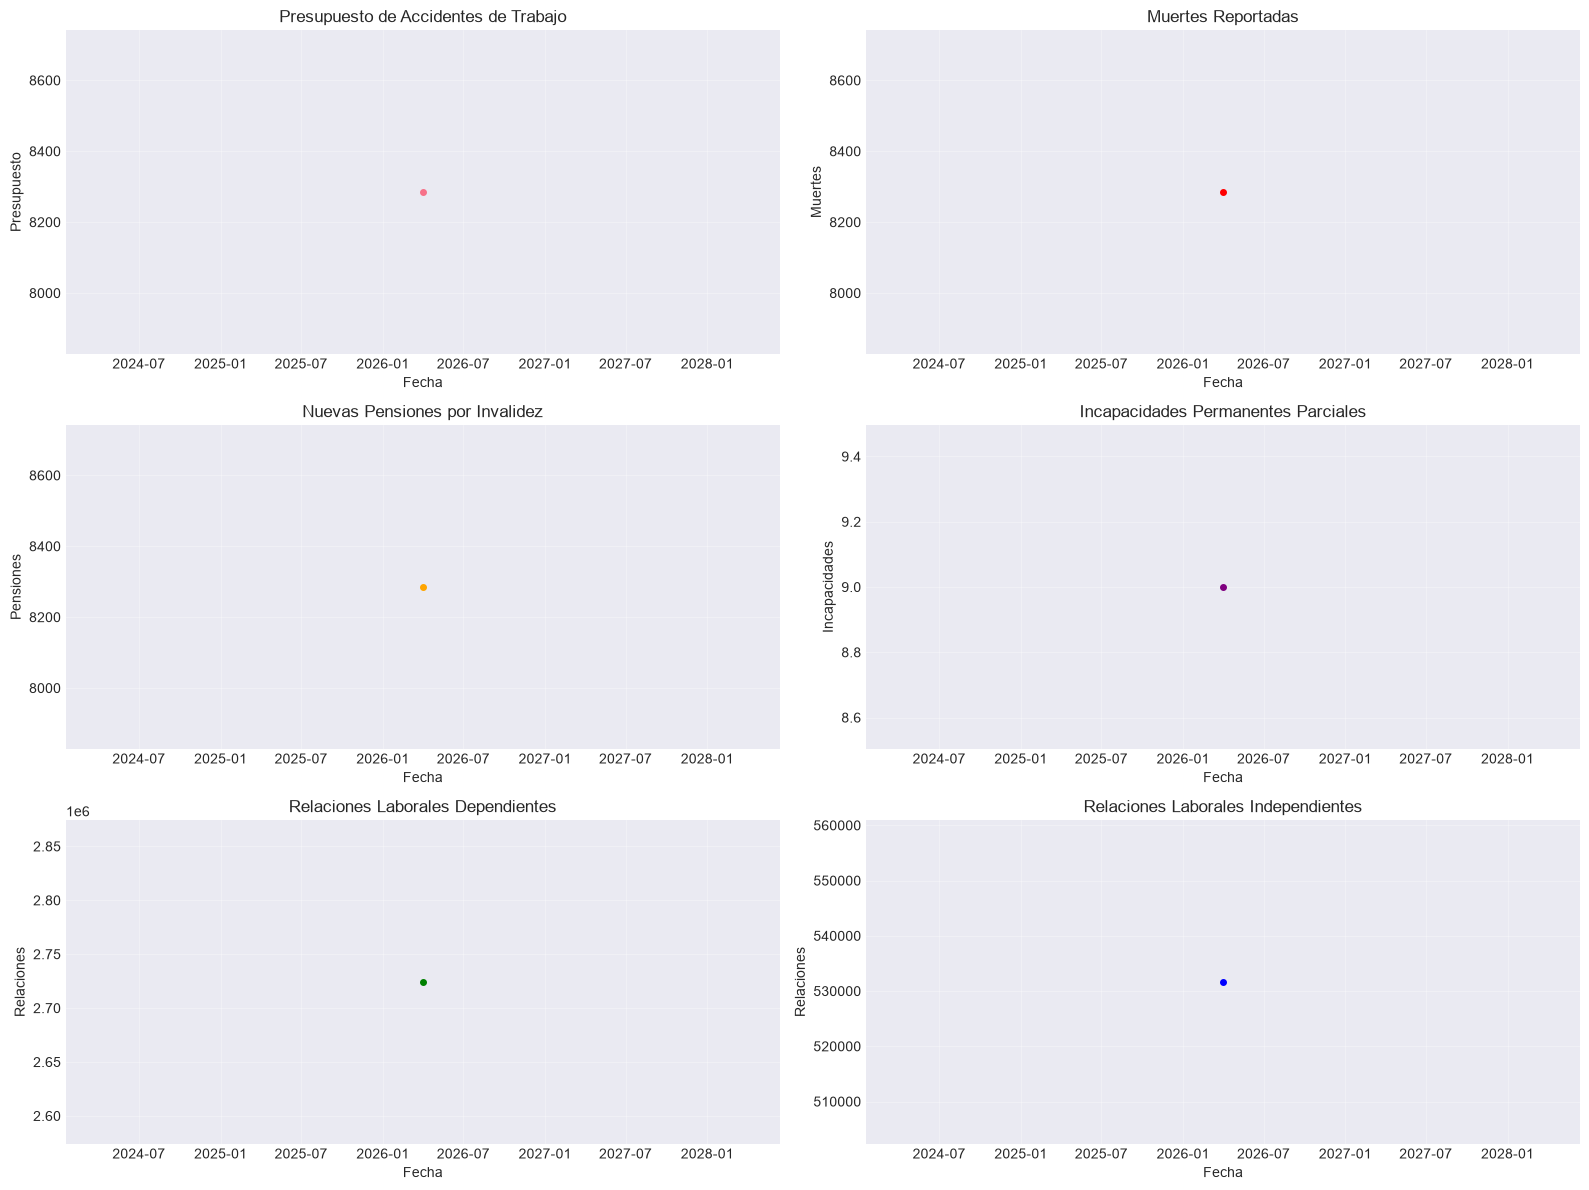


✅ Gráfico guardado en: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/reports/temporal_trends.png


In [30]:
# Visualizar tendencias temporales
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

# Presupuesto de accidentes
axes[0, 0].plot(df_temporal['FECHA'], df_temporal['PRESUACCIDETRASUCE'], 
                marker='o', linewidth=2, markersize=4)
axes[0, 0].set_title('Presupuesto de Accidentes de Trabajo')
axes[0, 0].set_xlabel('Fecha')
axes[0, 0].set_ylabel('Presupuesto')
axes[0, 0].grid(True, alpha=0.3)

# Muertes reportadas
axes[0, 1].plot(df_temporal['FECHA'], df_temporal['MUERTES_REPOR_AT'], 
                marker='o', linewidth=2, markersize=4, color='red')
axes[0, 1].set_title('Muertes Reportadas')
axes[0, 1].set_xlabel('Fecha')
axes[0, 1].set_ylabel('Muertes')
axes[0, 1].grid(True, alpha=0.3)

# Nuevas pensiones por invalidez
axes[1, 0].plot(df_temporal['FECHA'], df_temporal['NUEVAPENSIOINVA_R_AT'], 
                marker='o', linewidth=2, markersize=4, color='orange')
axes[1, 0].set_title('Nuevas Pensiones por Invalidez')
axes[1, 0].set_xlabel('Fecha')
axes[1, 0].set_ylabel('Pensiones')
axes[1, 0].grid(True, alpha=0.3)

# Incapacidades permanentes parciales
axes[1, 1].plot(df_temporal['FECHA'], df_temporal['INCAPERMAPARCIAR_AT'], 
                marker='o', linewidth=2, markersize=4, color='purple')
axes[1, 1].set_title('Incapacidades Permanentes Parciales')
axes[1, 1].set_xlabel('Fecha')
axes[1, 1].set_ylabel('Incapacidades')
axes[1, 1].grid(True, alpha=0.3)

# Relaciones laborales dependientes
axes[2, 0].plot(df_temporal['FECHA'], df_temporal['RELA_DEP'], 
                marker='o', linewidth=2, markersize=4, color='green')
axes[2, 0].set_title('Relaciones Laborales Dependientes')
axes[2, 0].set_xlabel('Fecha')
axes[2, 0].set_ylabel('Relaciones')
axes[2, 0].grid(True, alpha=0.3)

# Relaciones laborales independientes
axes[2, 1].plot(df_temporal['FECHA'], df_temporal['RELA_INDEP'], 
                marker='o', linewidth=2, markersize=4, color='blue')
axes[2, 1].set_title('Relaciones Laborales Independientes')
axes[2, 1].set_xlabel('Fecha')
axes[2, 1].set_ylabel('Relaciones')
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'temporal_trends.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✅ Gráfico guardado en: {REPORTS_DIR / 'temporal_trends.png'}")

### 6.3 Análisis de Estacionalidad

📊 Análisis de estacionalidad por mes...


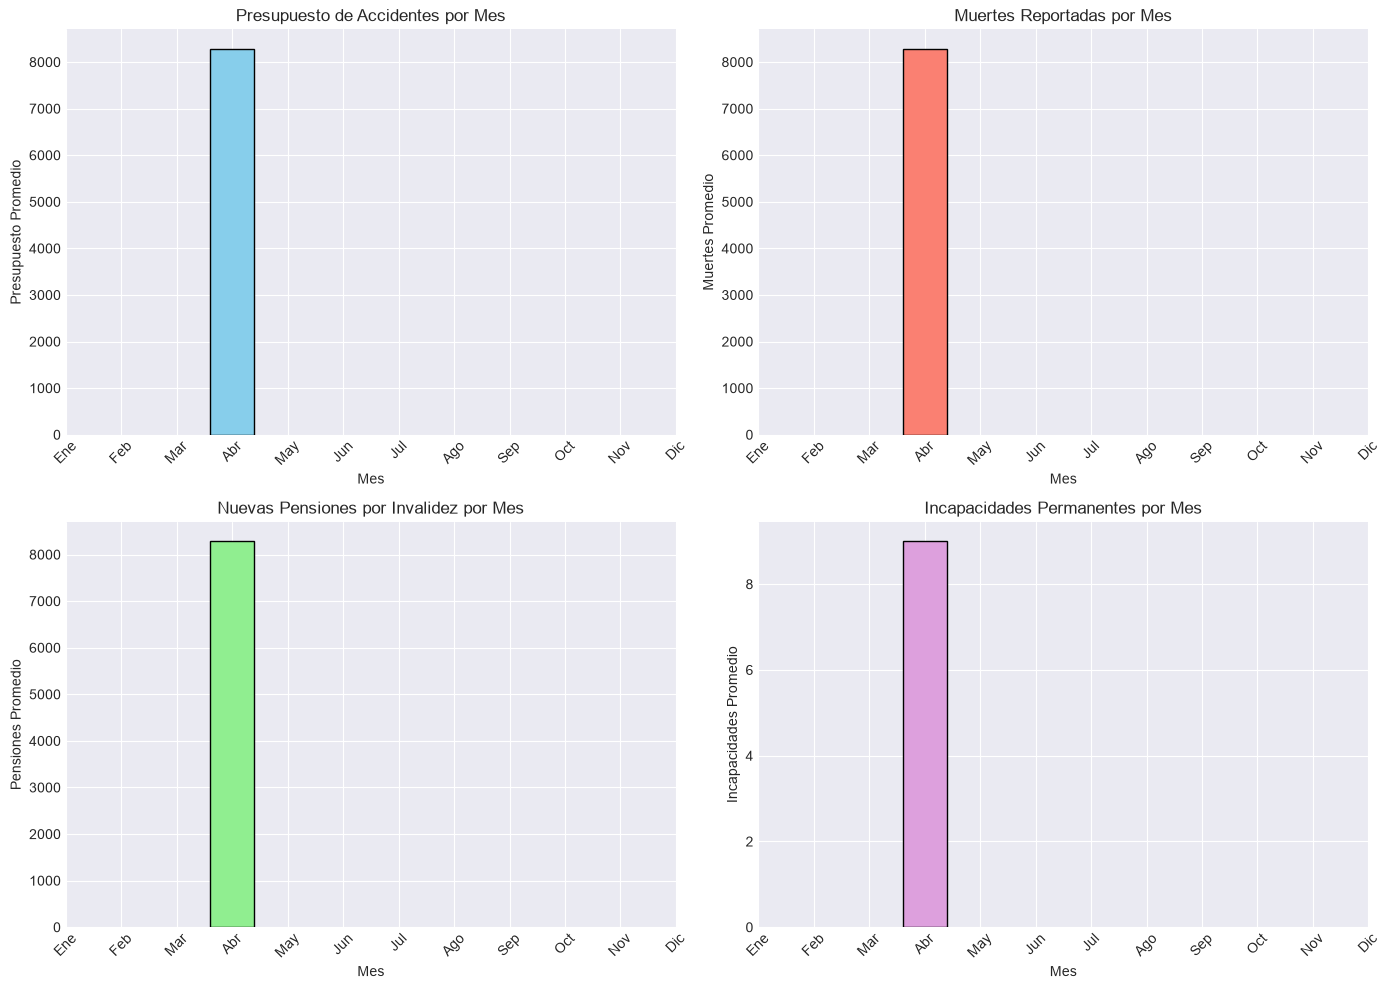


✅ Gráfico guardado en: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/reports/seasonality_analysis.png


In [31]:
# Análisis de estacionalidad por mes
print("📊 Análisis de estacionalidad por mes...")

# Agregar columna de mes
df_temporal['MES'] = df_temporal['FECHA'].dt.month

# Calcular promedio por mes
monthly_avg = df_temporal.groupby('MES').agg({
    'PRESUACCIDETRASUCE': 'mean',
    'MUERTES_REPOR_AT': 'mean',
    'NUEVAPENSIOINVA_R_AT': 'mean',
    'INCAPERMAPARCIAR_AT': 'mean'
}).reset_index()

# Visualizar estacionalidad
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

months = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 
          'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

# Presupuesto de accidentes
axes[0, 0].bar(monthly_avg['MES'], monthly_avg['PRESUACCIDETRASUCE'], 
               color='skyblue', edgecolor='black')
axes[0, 0].set_title('Presupuesto de Accidentes por Mes')
axes[0, 0].set_xlabel('Mes')
axes[0, 0].set_ylabel('Presupuesto Promedio')
axes[0, 0].set_xticks(range(1, 13))
axes[0, 0].set_xticklabels(months, rotation=45)

# Muertes reportadas
axes[0, 1].bar(monthly_avg['MES'], monthly_avg['MUERTES_REPOR_AT'], 
               color='salmon', edgecolor='black')
axes[0, 1].set_title('Muertes Reportadas por Mes')
axes[0, 1].set_xlabel('Mes')
axes[0, 1].set_ylabel('Muertes Promedio')
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].set_xticklabels(months, rotation=45)

# Nuevas pensiones
axes[1, 0].bar(monthly_avg['MES'], monthly_avg['NUEVAPENSIOINVA_R_AT'], 
               color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Nuevas Pensiones por Invalidez por Mes')
axes[1, 0].set_xlabel('Mes')
axes[1, 0].set_ylabel('Pensiones Promedio')
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].set_xticklabels(months, rotation=45)

# Incapacidades
axes[1, 1].bar(monthly_avg['MES'], monthly_avg['INCAPERMAPARCIAR_AT'], 
               color='plum', edgecolor='black')
axes[1, 1].set_title('Incapacidades Permanentes por Mes')
axes[1, 1].set_xlabel('Mes')
axes[1, 1].set_ylabel('Incapacidades Promedio')
axes[1, 1].set_xticks(range(1, 13))
axes[1, 1].set_xticklabels(months, rotation=45)

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'seasonality_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✅ Gráfico guardado en: {REPORTS_DIR / 'seasonality_analysis.png'}")

## 7. Guardar Resultados

Guardamos los modelos y resultados del análisis.

In [32]:
# Guardar modelos y resultados
print("💾 Guardando modelos y resultados...")

# Guardar modelos de clustering
joblib.dump(kmeans, MODELS_DIR / 'kmeans_model.pkl')
joblib.dump(dbscan, MODELS_DIR / 'dbscan_model.pkl')
joblib.dump(iso_forest, MODELS_DIR / 'isolation_forest_model.pkl')
joblib.dump(scaler_clustering, MODELS_DIR / 'scaler_clustering.pkl')
joblib.dump(pca, MODELS_DIR / 'pca_model.pkl')

# Guardar dataset con clusters y anomalías
df.to_csv(PROCESSED_DATA_DIR / 'dataset_with_clusters.csv', index=False)

# Guardar estadísticas de clusters
cluster_stats.to_csv(REPORTS_DIR / 'cluster_statistics.csv')

# Guardar análisis temporal
df_temporal.to_csv(REPORTS_DIR / 'temporal_analysis.csv', index=False)

print(f"✅ Modelos guardados en: {MODELS_DIR}")
print(f"✅ Dataset con clusters guardado en: {PROCESSED_DATA_DIR / 'dataset_with_clusters.csv'}")
print(f"✅ Reportes guardados en: {REPORTS_DIR}")

print(f"\n📋 Archivos guardados:")
print(f"   - kmeans_model.pkl")
print(f"   - dbscan_model.pkl")
print(f"   - isolation_forest_model.pkl")
print(f"   - scaler_clustering.pkl")
print(f"   - pca_model.pkl")
print(f"   - dataset_with_clusters.csv")
print(f"   - cluster_statistics.csv")
print(f"   - temporal_analysis.csv")

💾 Guardando modelos y resultados...
✅ Modelos guardados en: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/models
✅ Dataset con clusters guardado en: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/data/processed/dataset_with_clusters.csv
✅ Reportes guardados en: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/reports

📋 Archivos guardados:
   - kmeans_model.pkl
   - dbscan_model.pkl
   - isolation_forest_model.pkl
   - scaler_clustering.pkl
   - pca_model.pkl
   - dataset_with_clusters.csv
   - cluster_statistics.csv
   - temporal_analysis.csv


## 8. Conclusiones y Resumen

### 8.1 Resumen de Resultados

En este notebook hemos implementado técnicas de análisis de patrones para identificar grupos de riesgo, tendencias temporales y anomalías:

**Clustering (K-Means y DBSCAN):**
- Identificación de grupos de riesgo con características similares
- Análisis de características por cluster
- Visualización de clusters con PCA

**Detección de Anomalías (Isolation Forest):**
- Identificación de registros atípicos
- Análisis de características de anomalías
- Visualización de anomalías

**Análisis Temporal:**
- Tendencias de riesgos laborales a lo largo del tiempo
- Análisis de estacionalidad por mes
- Identificación de patrones temporales

### 8.2 Insights Principales

1. **Clusters identificados**: Se identificaron grupos de riesgo con características distintivas.
2. **Anomalías detectadas**: Se encontraron registros atípicos que requieren atención especial.
3. **Tendencias temporales**: Se observaron patrones estacionales en los riesgos laborales.

### 8.3 Próximos Pasos

1. **Notebook 5 (Explicabilidad):** Implementar análisis de importancia de características con SHAP.
2. **Análisis detallado de clusters:** Investigar características específicas de cada cluster.
3. **Modelado predictivo temporal:** Implementar modelos de series temporales.
4. **Validación de resultados:** Verificar la utilidad de los clusters y anomalías detectados.